In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy
import PIL


In [2]:
# Download the data from the website
import requests

url = "https://data.ontario.ca/dataset/5472ffc1-88e2-48ca-bc9f-4aa249c1298d/resource/d5d8f478-765c-4246-b8a7-c3b13a4a1a41/download/outbreak_cases.csv"
# Replace with the actual CSV file URL
response = requests.get(url)

# Save the file
with open("data.csv", "wb") as file:
    file.write(response.content)



In [3]:
# Read the downloaded file
import pandas as pd

df = pd.read_csv("data.csv")

print(df.head(5))  # Show the first few rows. It seems a meta data file.


  <!DOCTYPE html PUBLIC '-//W3C//DTD XHTML 1.0 Transitional//EN' 'http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd'>
0        <html xmlns='http://www.w3.org/1999/xhtml'>                                                                       
1                                             <head>                                                                       
2      <meta content='text/html; charset=utf-8' h...                                                                       
3                            <style type='text/css'>                                                                       
4                                             body {                                                                       


In [5]:
# Downloade the data file from the https://data.ontario.ca/dataset/5472ffc1-88e2-48ca-bc9f-4aa249c1298d/resource/d5d8f478-765c-4246-b8a7-c3b13a4a1a41/download/outbreak_cases.csv
# Read the data file from local disc

file_path = r"C:\Users\fansh\Downloads\outbreak_cases.csv"

df = pd.read_csv(file_path)

print(df)  # Show the data file


             date     category_grouped              outbreak_subgroup  \
0      2020-03-06  2 Congregate Living                        SHELTER   
1      2020-03-08    1 Congregate Care            LONG-TERM CARE HOME   
2      2020-03-09          4 Workplace              WORKPLACE - OTHER   
3      2020-03-11  2 Congregate Living  GROUP HOME/SUPPORTIVE HOUSING   
4      2020-03-13    1 Congregate Care            LONG-TERM CARE HOME   
...           ...                  ...                            ...   
11674  2023-04-03    1 Congregate Care                RETIREMENT HOME   
11675  2023-04-03  2 Congregate Living  GROUP HOME/SUPPORTIVE HOUSING   
11676  2023-04-04    1 Congregate Care            LONG-TERM CARE HOME   
11677  2023-04-04  2 Congregate Living          CORRECTIONAL FACILITY   
11678  2023-04-04  2 Congregate Living  GROUP HOME/SUPPORTIVE HOUSING   

       TOTAL_CASES  
0                1  
1                1  
2                1  
3                1  
4                1

[Text(0.5, 1.0, 'Daily Trend of COVID Outbreaks'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Total Cases')]

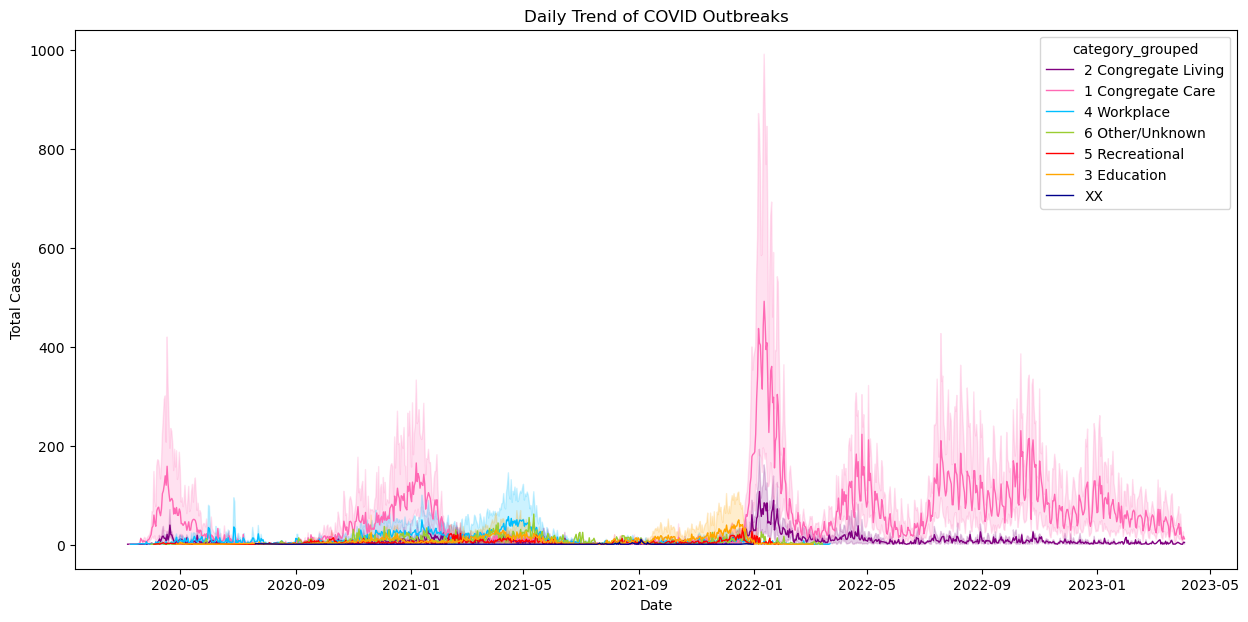

In [14]:
# Make the graph, note 'date' is daily
fig = plt.subplots(figsize=(15, 7))
Outbreakgraph = sns.lineplot(data=df, 
                           x='date',
                           y='TOTAL_CASES', 
                           #style = 'category_grouped ',
                           linewidth = 1, 
                           hue = 'category_grouped', 
                           palette = ['purple','hotpink', 'deepskyblue','yellowgreen', 'red','orange','darkblue']
                                      )

Outbreakgraph.set(title='Daily Trend of COVID Outbreaks',
            xlabel='Date',
            ylabel='Total Cases')

Suggestion: daily trend plot is too busy.

In [10]:
# Make monthly data file: calulate monthly TOTAL_CASES by category_grouped
# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Group by 'category_grouped' and resample by month
df_monthly = df.groupby(['category_grouped', pd.Grouper(key='date', freq='M')])['TOTAL_CASES'].sum().reset_index()

# Display the result
print(df_monthly)


      category_grouped       date  TOTAL_CASES
0    1 Congregate Care 2020-03-31          305
1    1 Congregate Care 2020-04-30         7301
2    1 Congregate Care 2020-05-31         3153
3    1 Congregate Care 2020-06-30          715
4    1 Congregate Care 2020-07-31          217
..                 ...        ...          ...
174                 XX 2021-04-30            3
175                 XX 2021-07-31           18
176                 XX 2021-08-31           37
177                 XX 2021-09-30           42
178                 XX 2021-12-31            5

[179 rows x 3 columns]


C:\Users\fansh\AppData\Local\Temp\ipykernel_15632\3651793953.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.groupby(['category_grouped', pd.Grouper(key='date', freq='M')])['TOTAL_CASES'].sum().reset_index()


[Text(0.5, 1.0, 'Monthly Trend of COVID Outbreaks'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Total Cases')]

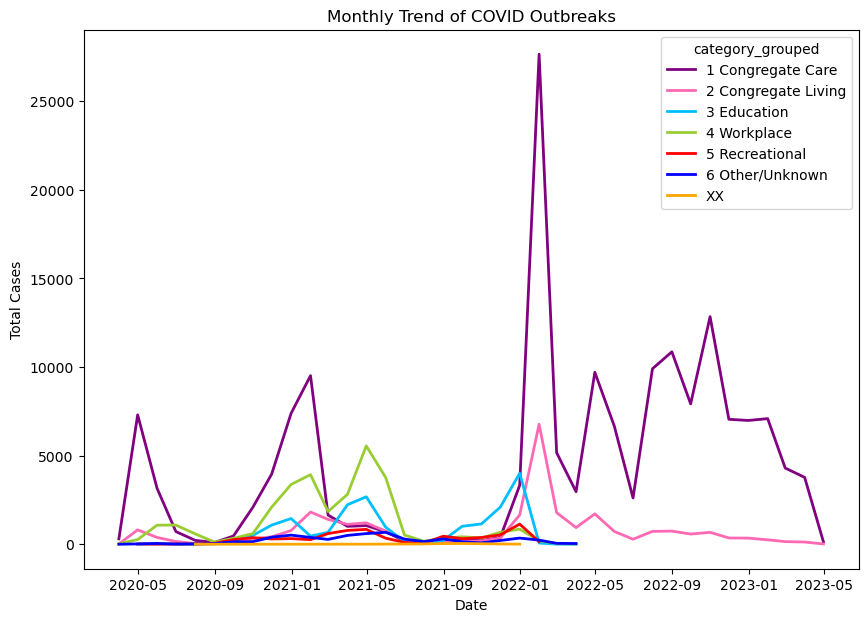

In [34]:
fig = plt.subplots(figsize=(10, 7))
MonthlyTrend = sns.lineplot(data=df_monthly, 
                           x='date',
                           y='TOTAL_CASES', 
                           linewidth = 2, 
                           hue = 'category_grouped', 
                           palette = ['purple','hotpink', 'deepskyblue','yellowgreen', 'red','blue','orange']
                                      )

MonthlyTrend.set(title='Monthly Trend of COVID Outbreaks',
            xlabel='Date',
            ylabel='Total Cases')

In [ ]:
# Group by 'category_grouped' and resample by quarter
df_quarterly = df.groupby(['category_grouped', pd.Grouper(key='date', freq='Q')])['TOTAL_CASES'].sum().reset_index()

# Display the result
print(df_quarterly)

     category_grouped       date  TOTAL_CASES
0   1 Congregate Care 2020-03-31          305
1   1 Congregate Care 2020-06-30        11169
2   1 Congregate Care 2020-09-30          785
3   1 Congregate Care 2020-12-31        13437
4   1 Congregate Care 2021-03-31        12165
..                ...        ...          ...
61    6 Other/Unknown 2022-03-31          324
62                 XX 2020-09-30            4
63                 XX 2021-06-30            3
64                 XX 2021-09-30           97
65                 XX 2021-12-31            5

[66 rows x 3 columns]


C:\Users\fansh\AppData\Local\Temp\ipykernel_15632\1081450084.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_quarterly = df.groupby(['category_grouped', pd.Grouper(key='date', freq='Q')])['TOTAL_CASES'].sum().reset_index()


[Text(0.5, 1.0, 'Quarterly Trend of COVID Outbreaks'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Total Cases')]

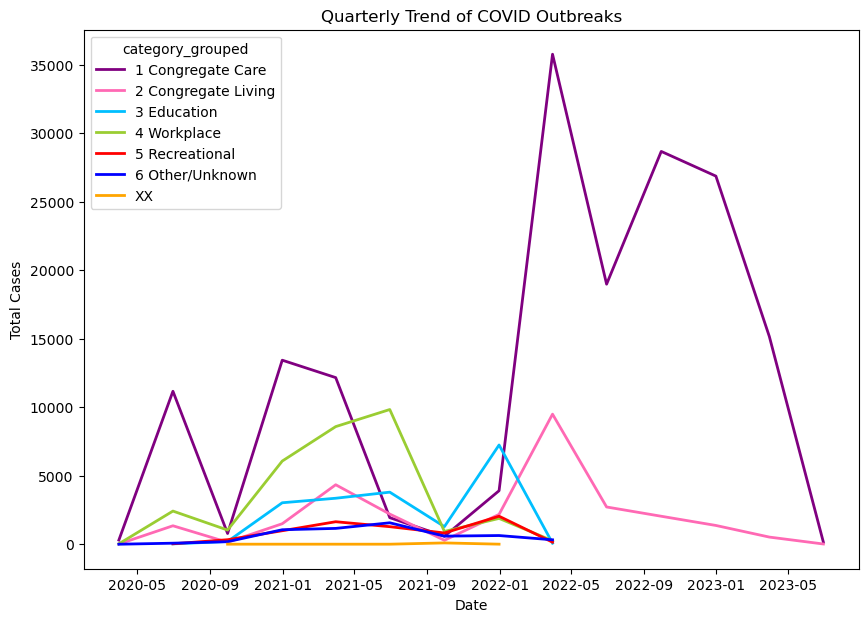

In [36]:
# Make Quarterly trend
fig = plt.subplots(figsize=(10, 7))
QuarterlyTrend = sns.lineplot(data=df_quarterly, 
                           x='date',
                           y='TOTAL_CASES', 
                           linewidth = 2, 
                           hue = 'category_grouped', 
                           palette = ['purple','hotpink', 'deepskyblue','yellowgreen', 'red','blue','orange']
                                      )

QuarterlyTrend.set(title='Quarterly Trend of COVID Outbreaks',
            xlabel='Date',
            ylabel='Total Cases')

Suggestion: Monthly trend plot tells more detailed information then quarterly trend plot.

[Text(0.5, 1.0, 'Quarterly Total Cases of COVID Outbreaks'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Total Cases')]

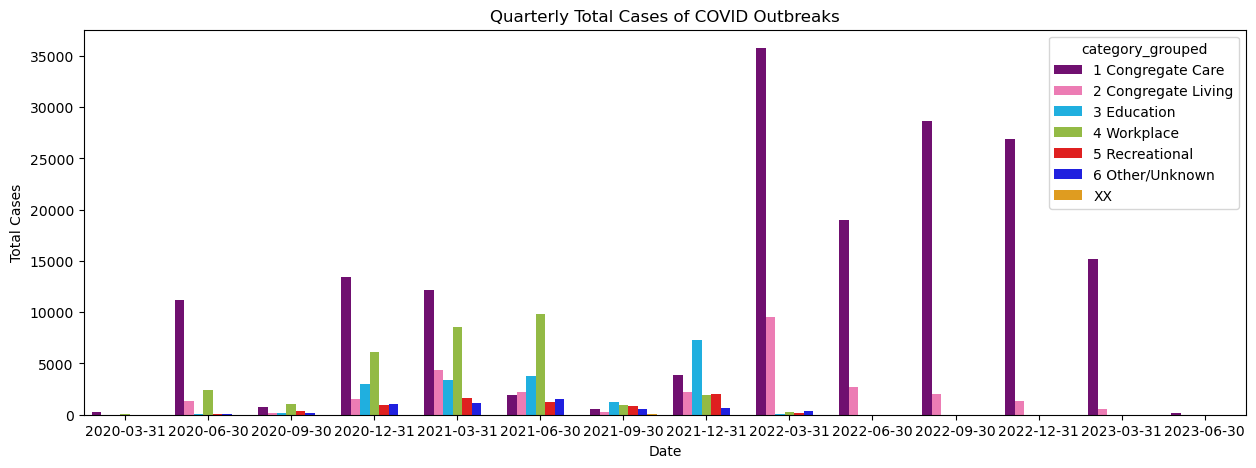

In [37]:
# Try bar graph
fig = plt.subplots(figsize=(15, 5))
QuarterlyBar = sns.barplot(data=df_quarterly, 
                           x='date',
                           y='TOTAL_CASES', 
                           hue = 'category_grouped', 
                           palette = ['purple','hotpink', 'deepskyblue','yellowgreen', 'red','blue','orange']
                                      )

QuarterlyBar.set(title='Quarterly Total Cases of COVID Outbreaks',
            xlabel='Date',
            ylabel='Total Cases')

Suggestion:the bar graph seems too busy. It's not good visualization for this dataset.

[Text(0.5, 1.0, 'Monthly Total Cases of COVID Outbreaks By Category'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Total Cases')]

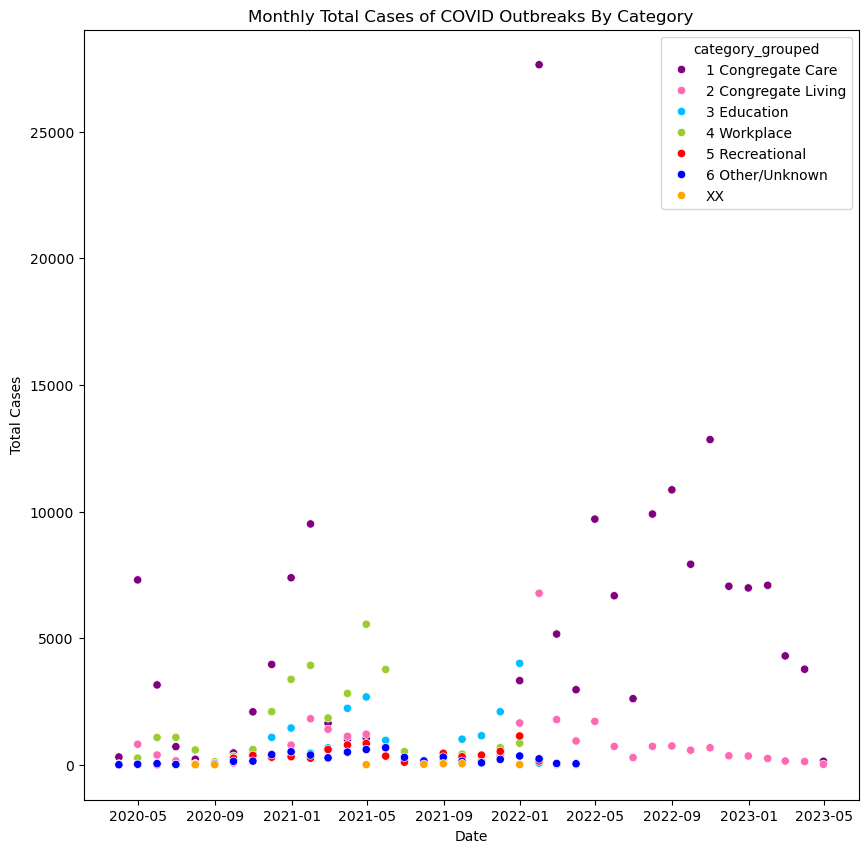

In [38]:
# Try scatter plot with monthly data
fig = plt.subplots(figsize=(10, 10))
MonthlyScat = sns.scatterplot(data=df_monthly, 
                           x='date',
                           y='TOTAL_CASES', 
                           hue = 'category_grouped', 
                           palette = ['purple','hotpink', 'deepskyblue','yellowgreen', 'red','blue','orange']
                                      )

MonthlyScat.set(title='Monthly Total Cases of COVID Outbreaks By Category',
            xlabel='Date',
            ylabel='Total Cases')

Suggestion: sctatter plot on monthly data is too busy.

[Text(0.5, 1.0, 'Quarterly Total Cases of COVID Outbreaks'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Total Cases')]

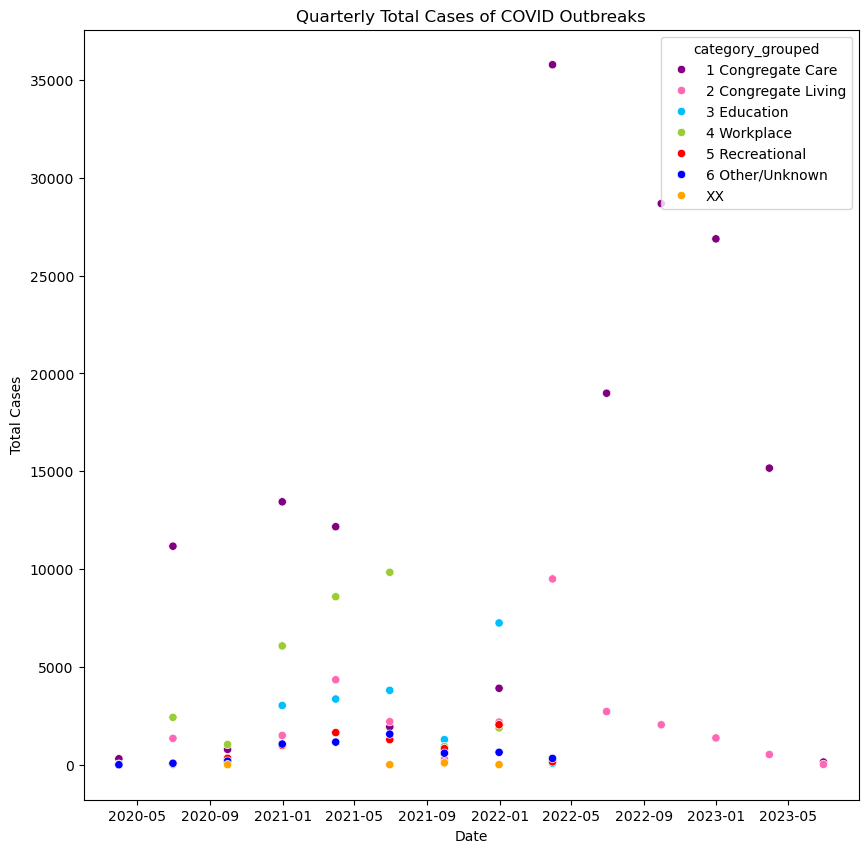

In [39]:
# Try scatter plot with quarterly data
fig = plt.subplots(figsize=(10, 10))
QuarterlyScat = sns.scatterplot(data=df_quarterly, 
                           x='date',
                           y='TOTAL_CASES', 
                           hue = 'category_grouped', 
                           palette = ['purple','hotpink', 'deepskyblue','yellowgreen', 'red','blue','orange']
                                      )

QuarterlyScat.set(title='Quarterly Total Cases of COVID Outbreaks',
            xlabel='Date',
            ylabel='Total Cases')